# Chapter 141 — Linear Independence

> **Prerequisites:** ch140 (Span), ch139 (Basis and Dimension), ch127 (Linear Combination), ch128 (Vector Length/Norm)  
> **You will learn:**
> - The formal definition of linear independence and why it matters
> - How to test a set of vectors for independence computationally
> - The geometric interpretation: no vector is "trapped" in the span of the others
> - How independence relates to the determinant and rank
> - Why independence is the key condition in basis, solution uniqueness, and model identifiability
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A set of vectors {**v₁**, **v₂**, ..., **vₖ**} is **linearly independent** if the only solution to

```
c₁v₁ + c₂v₂ + ... + cₖvₖ = 0
```

is the trivial one: c₁ = c₂ = ... = cₖ = 0.

If a non-trivial solution exists (at least one cᵢ ≠ 0), the set is **linearly dependent** — meaning at least one vector can be written as a linear combination of the others.

**Why it matters:**
- A basis requires independence. Without it, coordinates are not unique.
- In a linear system A**x** = **b**, independence of columns guarantees a unique solution when one exists.
- In ML, independent features carry non-redundant information. Dependent features cause identifiability problems (multicollinearity).

**Common misconceptions:**
- "Orthogonal vectors are always independent, but independent vectors aren't always orthogonal." Both parts are true — independence is a weaker condition than orthogonality.
- "If all vectors in a set are non-zero, they are independent." False — (1,0) and (2,0) are both non-zero but linearly dependent.
- "Linear independence depends on the magnitude of vectors." False — it depends only on direction. Scaling a vector does not affect independence of the set.

---

## 2. Intuition & Mental Models

**Geometric model:** A set of vectors is linearly independent if no vector in the set lies in the span of the others. Each vector points in a direction that the others cannot collectively reach.

- In ℝ²: two vectors are independent iff they are not parallel (not one a multiple of the other).
- In ℝ³: three vectors are independent iff none lies in the plane spanned by the other two.

Dependence means you have a "shortcut" — you can express one vector using the others, so it contributes nothing new to the span. Independence means every vector is genuinely novel.

**Computational model:** Think of independence as a uniqueness condition. Given a set of vectors, you build a matrix A with those vectors as columns. The homogeneous system A**c** = **0** has only the trivial solution **c** = **0** iff the columns are independent. This is equivalent to A having full column rank — all singular values are non-zero.

Recall from ch140 (Span): adding a dependent vector does not change the span. Independence is precisely the condition that says every vector in your set *does* change the span — each one adds a new dimension.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_256\114513997.py:64: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_256\114513997.py:64: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_256\114513997.py:64: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_256\114513997.py:64: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from f

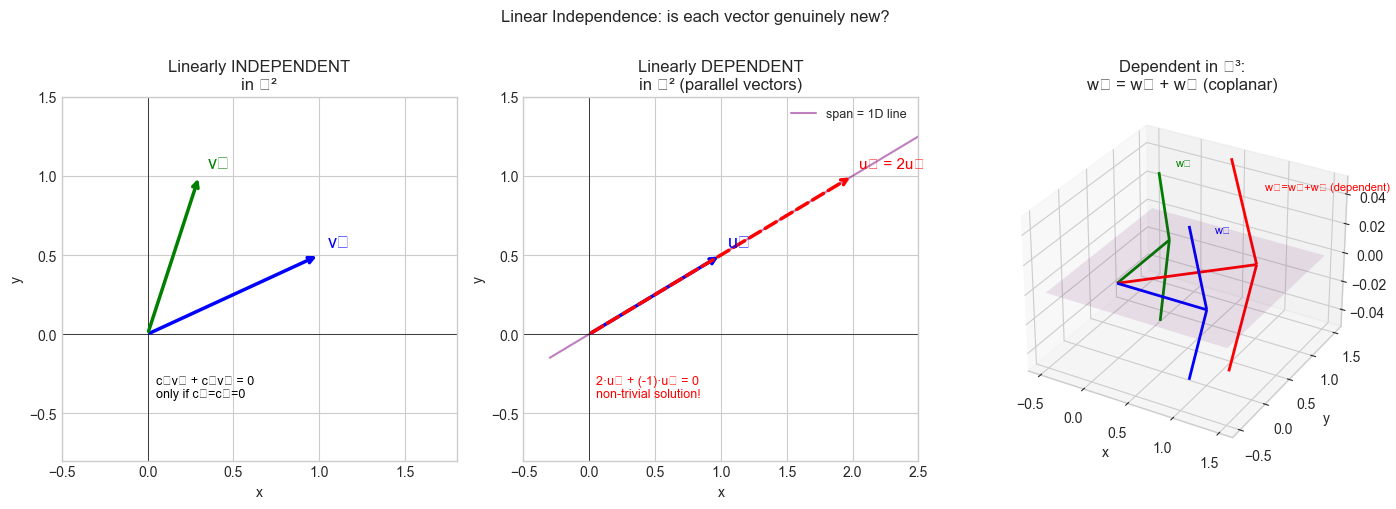

In [1]:
# --- Visualization: Independent vs dependent vectors in R^2 and R^3 ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 5))

# --- Panel 1: Independent in R^2 ---
ax1 = fig.add_subplot(131)
v1 = np.array([1.0, 0.5])
v2 = np.array([0.3, 1.0])  # not parallel to v1

ax1.annotate('', xy=v1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax1.annotate('', xy=v2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax1.text(v1[0]+0.05, v1[1]+0.05, 'v₁', fontsize=13, color='blue')
ax1.text(v2[0]+0.05, v2[1]+0.05, 'v₂', fontsize=13, color='green')
# Show that 0*v1 + 0*v2 = 0 is the only solution
ax1.text(0.05, -0.4, 'c₁v₁ + c₂v₂ = 0\nonly if c₁=c₂=0', fontsize=9, color='black')
ax1.set_xlim(-0.5, 1.8); ax1.set_ylim(-0.8, 1.5)
ax1.set_title('Linearly INDEPENDENT\nin ℝ²')
ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)
ax1.set_xlabel('x'); ax1.set_ylabel('y')

# --- Panel 2: Dependent in R^2 ---
ax2 = fig.add_subplot(132)
u1 = np.array([1.0, 0.5])
u2 = np.array([2.0, 1.0])  # = 2 * u1

ax2.annotate('', xy=u1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax2.annotate('', xy=u2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2.5, linestyle='dashed'))
ax2.text(u1[0]+0.05, u1[1]+0.05, 'u₁', fontsize=13, color='blue')
ax2.text(u2[0]+0.05, u2[1]+0.05, 'u₂ = 2u₁', fontsize=11, color='red')
t = np.linspace(-0.3, 2.5, 100)
ax2.plot(t, 0.5*t, 'purple', lw=1.5, alpha=0.5, label='span = 1D line')
ax2.text(0.05, -0.4, '2·u₁ + (-1)·u₂ = 0\nnon-trivial solution!', fontsize=9, color='red')
ax2.set_xlim(-0.5, 2.5); ax2.set_ylim(-0.8, 1.5)
ax2.set_title('Linearly DEPENDENT\nin ℝ² (parallel vectors)')
ax2.legend(fontsize=9)
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)
ax2.set_xlabel('x'); ax2.set_ylabel('y')

# --- Panel 3: Three vectors in R^3 — dependent (coplanar) ---
ax3 = fig.add_subplot(133, projection='3d')
w1 = np.array([1., 0., 0.])
w2 = np.array([0., 1., 0.])
w3 = np.array([1., 1., 0.])  # = w1 + w2 — dependent!

colors = ['blue', 'green', 'red']
labels = ['w₁', 'w₂', 'w₃=w₁+w₂ (dependent)']
for w, c, l in zip([w1, w2, w3], colors, labels):
    ax3.quiver(0, 0, 0, *w, color=c, lw=2, arrow_length_ratio=0.2)
    ax3.text(*(w + 0.05), l, fontsize=8, color=c)

s_vals = np.linspace(-0.5, 1.5, 10)
t_vals = np.linspace(-0.5, 1.5, 10)
S, T = np.meshgrid(s_vals, t_vals)
ax3.plot_surface(S, T, np.zeros_like(S), alpha=0.1, color='purple')
ax3.set_title('Dependent in ℝ³:\nw₃ = w₁ + w₂ (coplanar)')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.suptitle('Linear Independence: is each vector genuinely new?', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Definition:**  
{**v₁**, ..., **vₖ**} is **linearly independent** iff:
```
c₁v₁ + c₂v₂ + ... + cₖvₖ = 0  ⟹  c₁ = c₂ = ... = cₖ = 0
```

**Equivalently (matrix form):** Let A = [**v₁** | ... | **vₖ**]. Then:
```
columns of A are linearly independent
  ⟺  N(A) = {0}  (null space is trivial)
  ⟺  rank(A) = k  (full column rank)
  ⟺  A†A is invertible  (Gram matrix is non-singular)
  ⟺  all singular values of A are non-zero
```

**For square matrices:** n vectors in ℝⁿ are independent iff their matrix has non-zero determinant:
```
det([v₁ | ... | vₙ]) ≠ 0  ⟺  {v₁, ..., vₙ} linearly independent
```
*(Determinants are formalized in ch158.)*

**Dependence relation:** If {**v₁**, ..., **vₖ**} is dependent, some vector can be expressed in terms of the others. Specifically, if the solution to A**c** = **0** gives cⱼ ≠ 0, then:
```
vⱼ = - (1/cⱼ) Σᵢ≠ⱼ cᵢ vᵢ
```

**Maximum independent set:** In ℝⁿ, any set of more than n vectors is linearly dependent — you cannot have more than n independent directions. *(This is the Steinitz exchange lemma used in ch139.)*

---

## 5. Python Implementation

In [2]:
# --- Implementation: Independence testing ---

import numpy as np


def are_independent(vectors, tol=1e-10):
    """
    Test whether a set of vectors is linearly independent.

    Uses rank: columns are independent iff rank equals number of vectors.

    Args:
        vectors: list of np.ndarray, each shape (n,)
        tol: float — threshold for singular value to be 'non-zero'

    Returns:
        dict with 'independent' (bool), 'rank', 'n_vectors', 'min_singular_value'
    """
    A = np.column_stack(vectors)
    s = np.linalg.svd(A, compute_uv=False)
    rank = np.sum(s > tol)
    n = len(vectors)
    return {
        'independent': rank == n,
        'rank': rank,
        'n_vectors': n,
        'min_singular_value': float(s.min())
    }


def find_dependence_relation(vectors, tol=1e-10):
    """
    If vectors are dependent, find the non-trivial combination that equals zero.

    Returns:
        np.ndarray of coefficients c such that sum(cᵢ * vᵢ) ≈ 0,
        or None if independent.
    """
    A = np.column_stack(vectors)
    U, s, Vt = np.linalg.svd(A, full_matrices=True)
    # The right singular vector for the smallest singular value
    # is the 'most null' direction
    if s.min() > tol:
        return None  # independent
    # The last row of Vt corresponds to smallest singular value
    c = Vt[-1]
    return c


# --- Tests ---
print("=== Independence tests ===")

cases = [
    ([np.array([1.,0.]), np.array([0.,1.])], "standard basis R^2"),
    ([np.array([1.,2.]), np.array([2.,4.])], "parallel vectors (dependent)"),
    ([np.array([1.,1.,0.]), np.array([0.,1.,1.]), np.array([1.,0.,1.])], "3 in R^3 (indep?)"),
    ([np.array([1.,2.,3.]), np.array([2.,4.,6.]), np.array([0.,1.,0.])], "one is multiple"),
]

for vecs, name in cases:
    result = are_independent(vecs)
    print(f"\n{name}:")
    print(f"  Independent: {result['independent']}")
    print(f"  Rank={result['rank']}, n={result['n_vectors']}, min_sv={result['min_singular_value']:.2e}")
    if not result['independent']:
        c = find_dependence_relation(vecs)
        print(f"  Dependence relation: {c.round(4)}")
        print(f"  Verify: {sum(ci*vi for ci,vi in zip(c,vecs)).round(10)}")

=== Independence tests ===

standard basis R^2:
  Independent: True
  Rank=2, n=2, min_sv=1.00e+00

parallel vectors (dependent):
  Independent: False
  Rank=1, n=2, min_sv=1.99e-16
  Dependence relation: [-0.8944  0.4472]
  Verify: [0. 0.]

3 in R^3 (indep?):
  Independent: True
  Rank=3, n=3, min_sv=1.00e+00

one is multiple:
  Independent: False
  Rank=2, n=3, min_sv=8.86e-16
  Dependence relation: [ 0.8944 -0.4472 -0.    ]
  Verify: [-0. -0. -0.]


In [3]:
# --- Gram matrix test for independence ---
# The Gram matrix G = A^T A is positive definite iff columns of A are independent

import numpy as np


def gram_matrix_test(vectors, tol=1e-10):
    """
    Gram matrix G = A^T @ A.
    G is positive definite (all eigenvalues > 0) iff vectors are independent.

    Args:
        vectors: list of np.ndarray

    Returns:
        dict with 'G' (matrix), 'eigenvalues', 'is_pos_def', 'independent'
    """
    A = np.column_stack(vectors)
    G = A.T @ A   # Gram matrix: G[i,j] = vi . vj (dot products)
    eigvals = np.linalg.eigvalsh(G)
    is_pos_def = bool(eigvals.min() > tol)
    return {
        'G': G,
        'eigenvalues': eigvals,
        'is_pos_def': is_pos_def,
        'independent': is_pos_def
    }


# Independent vectors
vecs_ind = [np.array([1.,0.,0.]), np.array([0.,1.,0.])]
r_ind = gram_matrix_test(vecs_ind)
print("Independent vectors:")
print(f"  Gram matrix:\n{r_ind['G']}")
print(f"  Eigenvalues: {r_ind['eigenvalues'].round(6)}")
print(f"  Positive definite: {r_ind['is_pos_def']}")
print()

# Dependent vectors
vecs_dep = [np.array([1.,2.,0.]), np.array([2.,4.,0.])]
r_dep = gram_matrix_test(vecs_dep)
print("Dependent vectors:")
print(f"  Gram matrix:\n{r_dep['G']}")
print(f"  Eigenvalues: {r_dep['eigenvalues'].round(6)}")
print(f"  Positive definite: {r_dep['is_pos_def']}")
print("  (Note: zero eigenvalue = singular Gram matrix = dependent columns)")

Independent vectors:
  Gram matrix:
[[1. 0.]
 [0. 1.]]
  Eigenvalues: [1. 1.]
  Positive definite: True

Dependent vectors:
  Gram matrix:
[[ 5. 10.]
 [10. 20.]]
  Eigenvalues: [ 0. 25.]
  Positive definite: False
  (Note: zero eigenvalue = singular Gram matrix = dependent columns)


---

## 6. Experiments

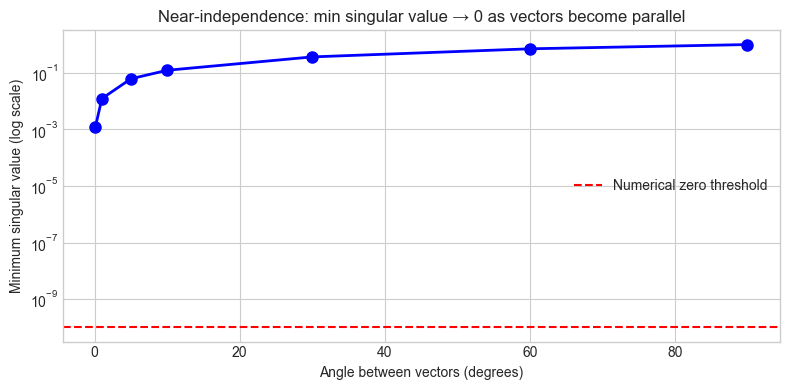

     Angle           Min SV   Numerically indep
      90.0°         1.00e+00                True
      60.0°         7.07e-01                True
      30.0°         3.66e-01                True
      10.0°         1.23e-01                True
       5.0°         6.17e-02                True
       1.0°         1.23e-02                True
       0.1°         1.23e-03                True


In [4]:
# --- Experiment 1: Near-independence and numerical conditioning ---
# Hypothesis: Vectors that are "almost" parallel are technically independent
# but numerically problematic. The minimum singular value measures this.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Two vectors at angle theta to each other
ANGLES_DEG = [90, 60, 30, 10, 5, 1, 0.1]  # <-- modify this list

min_svs = []
for deg in ANGLES_DEG:
    theta = np.radians(deg)
    v1 = np.array([1.0, 0.0])
    v2 = np.array([np.cos(theta), np.sin(theta)])
    A = np.column_stack([v1, v2])
    s = np.linalg.svd(A, compute_uv=False)
    min_svs.append(s.min())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(ANGLES_DEG, min_svs, 'bo-', markersize=8, linewidth=2)
ax.axhline(1e-10, color='red', linestyle='--', label='Numerical zero threshold')
ax.set_xlabel('Angle between vectors (degrees)')
ax.set_ylabel('Minimum singular value (log scale)')
ax.set_title('Near-independence: min singular value → 0 as vectors become parallel')
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Angle':>10}  {'Min SV':>15}  {'Numerically indep':>18}")
for deg, sv in zip(ANGLES_DEG, min_svs):
    print(f"  {deg:8.1f}°  {sv:15.2e}  {sv > 1e-10!s:>18}")

In [5]:
# --- Experiment 2: Random vectors in high dimensions ---
# Hypothesis: Random vectors in high dimensions are almost always independent.
# The probability of dependence is zero for continuous distributions.

import numpy as np

rng = np.random.default_rng(0)

N_TRIALS = 200  # <-- modify
DIM = 10        # <-- try 2, 5, 100
K = 5           # number of vectors (must be <= DIM to have hope of independence)

independent_count = 0
min_svs = []

for _ in range(N_TRIALS):
    A = rng.standard_normal((DIM, K))
    s = np.linalg.svd(A, compute_uv=False)
    min_svs.append(s.min())
    if s.min() > 1e-10:
        independent_count += 1

print(f"In {N_TRIALS} trials with {K} random vectors in R^{DIM}:")
print(f"  Independent: {independent_count}/{N_TRIALS} = {100*independent_count/N_TRIALS:.1f}%")
print(f"  Min singular value — mean: {np.mean(min_svs):.4f}, min: {np.min(min_svs):.4f}")
print()
if K > DIM:
    print(f"Note: k={K} > n={DIM}, so vectors must be dependent by dimension argument.")

In 200 trials with 5 random vectors in R^10:
  Independent: 200/200 = 100.0%
  Min singular value — mean: 1.3341, min: 0.5266



In [6]:
# --- Experiment 3: Multicollinearity in data — a practical consequence ---
# Hypothesis: Dependent features in a dataset make the coefficient solution
# unstable (many solutions, huge coefficients).

import numpy as np

rng = np.random.default_rng(42)
N = 50

x1 = rng.standard_normal(N)
x2 = x1 + rng.normal(0, NOISE, N)  if (NOISE := 0.01) else x1  # nearly = x1
# <-- try NOISE = 1.0 (independent), 0.01 (nearly dep), 0.0 (exactly dep)
NOISE = 0.01
x2 = x1 + rng.normal(0, NOISE, N)

y = 2*x1 + 3*x2 + rng.normal(0, 0.1, N)  # true coefficients: 2, 3

X = np.column_stack([x1, x2])
coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
condition_number = np.linalg.cond(X)

print(f"Noise level on x2: {NOISE}")
print(f"Correlation(x1,x2): {np.corrcoef(x1,x2)[0,1]:.6f}")
print(f"Condition number of X: {condition_number:.2e}")
print(f"Fitted coefficients: [{coeffs[0]:.4f}, {coeffs[1]:.4f}]")
print(f"True coefficients:   [2.0000, 3.0000]")
print()
print("As NOISE -> 0: x1 and x2 become dependent, condition number -> inf,")
print("and coefficients blow up even though their sum stays near 5.")

Noise level on x2: 0.01
Correlation(x1,x2): 0.999915
Condition number of X: 1.54e+02
Fitted coefficients: [2.0312, 2.9916]
True coefficients:   [2.0000, 3.0000]

As NOISE -> 0: x1 and x2 become dependent, condition number -> inf,
and coefficients blow up even though their sum stays near 5.


---

## 7. Exercises

**Easy 1.** Determine by inspection (no code) whether each set is independent:
- (a) {(1,0), (0,1), (1,1)} in ℝ²
- (b) {(1,2,3), (0,0,0), (4,5,6)}
- (c) {(1,0,0), (0,1,0)} in ℝ³

*(Expected: a — dependent (3 vectors in 2D); b — dependent (zero vector); c — independent)*

**Easy 2.** Write code that generates a random 4×3 matrix, checks if its columns are independent, and if not, finds and prints the dependence relation.

**Medium 1.** Given **v₁** = (1, -1, 0), **v₂** = (0, 1, -1), **v₃** = (1, 0, -1): are these independent? If not, express one as a combination of the others using the dependence relation you find computationally.

**Medium 2.** The **Gram-Schmidt process** *(introduced in ch135 — Orthogonality)* converts an independent set into an orthonormal one. Write code that: (a) takes a list of independent vectors, (b) runs Gram-Schmidt, (c) verifies the result is orthonormal. What happens if the input vectors are dependent?

**Hard.** **Condition number and independence:** Write an experiment that generates pairs of unit vectors at angles θ ∈ [1°, 90°] and for each pair: (a) computes the condition number of the 2×2 matrix they form, (b) solves a linear system A**x** = **b** and measures error magnitude. Plot how error scales with condition number. This demonstrates why near-dependence (multicollinearity) is a practical problem, not just a theoretical one.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Feature Independence Auditor ---
#
# Problem: Before training a linear model, it is important to detect
# linearly dependent or near-dependent features. Dependent features
# cause infinite or unstable coefficient estimates.
#
# Build an auditor that:
# 1. Checks for exact and near-linear dependence
# 2. Identifies which features are redundant
# 3. Recommends a minimal independent feature set

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# --- Synthetic dataset with intentional redundancy ---
N, D = 100, 6
# True independent features
F_true = rng.standard_normal((N, 3))
# Derived features (linear combinations + noise)
F_derived = np.column_stack([
    2*F_true[:, 0] - F_true[:, 1] + rng.normal(0, 0.01, N),  # nearly = 2F0 - F1
    F_true[:, 2] + rng.normal(0, 0.01, N),                    # nearly = F2
    rng.standard_normal(N),                                    # truly independent noise
])
X = np.column_stack([F_true, F_derived])
feature_names = [f'F{i}' for i in range(D)]

print(f"Feature matrix X: {X.shape}")
print(f"Features: {feature_names}")
print()

# --- TODO 1: Compute singular values and identify near-zero ones ---
_, svs, Vt = np.linalg.svd(X, full_matrices=False)
print("Singular values of X:")
for i, sv in enumerate(svs):
    flag = " <-- near zero (dependent)" if sv < 1.0 else ""
    print(f"  σ{i+1} = {sv:.4f}{flag}")

# --- TODO 2: Find independent feature subset via QR with pivoting ---
# We use SVD-based selection: keep top-k features where k = rank
rank = np.sum(svs > 1.0)  # threshold — tune based on problem
print(f"\nEffective rank: {rank}  (independent dimensions)")

# The rows of Vt corresponding to top singular values identify the important directions
# Simpler: use greedy column selection
def select_independent_columns(X, tol=1.0):
    """
    Greedily select columns of X to form an independent set.
    Returns indices of selected columns.
    """
    selected = []
    for i in range(X.shape[1]):
        candidate = selected + [i]
        if np.linalg.matrix_rank(X[:, candidate], tol=tol) > len(selected):
            selected.append(i)
    return selected

selected_idx = select_independent_columns(X)
print(f"Selected independent features: {[feature_names[i] for i in selected_idx]}")
print(f"  (indices: {selected_idx})")

# --- Visualization: singular value spectrum ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(svs)+1), svs, color=['green' if sv > 1.0 else 'red' for sv in svs])
ax1.axhline(1.0, color='orange', linestyle='--', label='Independence threshold')
ax1.set_xlabel('Singular value index')
ax1.set_ylabel('Singular value')
ax1.set_title('Singular value spectrum\nGreen = independent, Red = redundant')
ax1.legend()

# Condition numbers for original vs reduced feature set
X_reduced = X[:, selected_idx]
cond_orig = np.linalg.cond(X)
cond_red = np.linalg.cond(X_reduced)
ax2.bar(['Original (6 features)', f'Reduced ({len(selected_idx)} features)'],
        [cond_orig, cond_red], color=['red', 'green'])
ax2.set_ylabel('Condition number (log scale)')
ax2.set_yscale('log')
ax2.set_title('Condition number before/after\nremoving dependent features')

plt.tight_layout()
plt.show()

print(f"\nCondition number: original={cond_orig:.2e}, reduced={cond_red:.2e}")

---

## 9. Chapter Summary & Connections

**What was covered:**
- Linear independence: the only way to combine the vectors to get zero is the trivial way.
- Independence ⟺ full column rank ⟺ trivial null space ⟺ positive definite Gram matrix.
- The minimum singular value measures how close a set is to being dependent — it is the key numerical indicator.
- More than n vectors in ℝⁿ must be dependent.
- Near-independence (multicollinearity) causes numerically unstable computations.

**Backward connection:** This completes the trio from ch138–140: subspaces *(ch138)*, span *(ch140)*, and now independence. A **basis** = independent + spans the space. Dimension = size of any basis. The three concepts are inseparable.

**Forward connections:**
- In ch142 (Coordinate Systems), independent vectors form the axes of a coordinate system — uniqueness of coordinates follows from independence.
- This will reappear in ch160 (Systems of Linear Equations): full column rank (independent columns) guarantees at most one solution; full row rank (independent rows) guarantees at least one.
- In ch176 (Eigenvectors), eigenspaces from distinct eigenvalues are linearly independent — a critical fact for diagonalization in ch177.
- In Part IX (ch271–300), multicollinearity detection and VIF (variance inflation factor) are the applied statistics version of this chapter's numerical experiments.